In [43]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..", "Code")))
import os
import json

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

from tools_.preprocess_data import Preprocess_Dataset
from scripts.visualization.utils.renderizer import EGMRenderer_BSP

from tools_.load_dataset import LoadDataset_BSPS
from scripts.visualization.utils.bsp_3d_plotter import BSP_3D_PLOTTER
from scripts.visualization.utils.egm_3d_plotter import EGM_3D_PLOTTER
from scripts.visualization.utils.corr_3d_plotter import CORRELATION_3D_PLOTTER
from models.multioutput_VAE import MultiOutput_VAE, SamplingLayer


from scripts.Tikhonov.compute_tik import TikhonovReconstruction
from scripts.evaluate_function import *
from tools_.tools import corr_pearson_cols
from tools_.tools_inference import *
from scripts.evaluation.tools_evaluate import normalize_array, downsampling
from scripts.evaluation.metrics import rmse_by_node, correlation_by_node




In [44]:
torso_num=2
model_path=f"/home/pdi/miriamgf/tesis/Autoencoders/Labeled_torsos/Torso{torso_num}_mod.mat"
model_name = ["Simulation_01_210208_001_002"] 
algorithm_ID= "OMAMI_repeated"
TIK_ON=False

In [45]:
# Cargar datos

geom_path_CF = "/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_computacionales_Carlos_Fambuena/Atria.mat"
geom_path_edgar= "/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_Edgar/Atria.mat"
output_directory = f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/{algorithm_ID}"
os.makedirs(output_directory, exist_ok=True)
data_dir = "/home/profes/miriamgf/tesis/Autoencoders/Data/"
torsos_dir = "/home/profes/miriamgf/tesis/Autoencoders/Labeled_torsos/"

experiment_dir=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID}/"
model_path=experiment_dir+f"reconstructions_by_model_{algorithm_ID}.mat"
weights_path = experiment_dir + "model_weights.h5"
params_path=experiment_dir+'hyperparams.json'

In [46]:
#Load params dictionary
with open(experiment_dir+"hyperparams.json") as file:
    params = json.load(file)  # Load the JSON data into a dictionary

if params["algorithm"]=="OMAMI_VAE":
    fs=100
    n_batch=200
elif params["algorithm"]=="OMAMI":
    fs=200
    n_batch=400

params["filter_EGM"]=True


print(params)
print('fs:', fs, ' batch size: ', n_batch)

{'n_epochs': 50, 'batch_size': 400, 'fs_sub': 200, 'algorithm': 'OMAMI', 'set_gpu': False, 'cross_validation': False, 'fold': 0, 'rnn_layers': 1, 'dropout': 0.5, 'learning_rate': 0.001, 'early_stopping_patience': 20, 'beta1': 0.11, 'beta2': 0.99, 'mlflow_tracking': True, 'n_nodes_regression': 2048, 'use_generator': False, 'parallelism': False, 'fs': 500, 'n_classes': 3, 'inference_pretrained_model': False, 'optimizer': 'adam', 'loss_weight_1': 8.0, 'loss_weight_2': 2.0, 'l2_reg': 0.1, 'LSTM_units': 25, '3D_depth': 10, 'latent_dim': 2, 'optuna_optimization': False, 'n_trials': 30, 'optuna_parameters': {'sampler_algorithm': ['tpe'], 'loss_weight_1': ['grid', [1, 2, 4, 6, 8, 10]], 'loss_weight_2': ['grid', [2, 4, 6, 8, 10]], '3D_depth': ['grid', [3, 5, 10]], 'l2_reg': ['grid', [0.1, 0.001]], 'LSTM_units': ['grid', [10, 25, 40]]}, 'execution_time': 87.49673668940862, 'filter_EGM': True}
fs: 200  batch size:  400


In [47]:

    
# Cargar datos del modelo y la geometría
all_torsos_names = []
for subdir, dirs, files in os.walk(torsos_dir):
    for file in files:
        if file.endswith(".mat"):
            all_torsos_names.append(file)

#Load geometry

SNR_em_noise = None
SNR_white_noise = 100
patches_oclussion = "PT"
experiment_number = 0
unfold_code = 1


# Load test model
(
    X_1channel,
    Y,
    Y_model,
    egm_tensor,
    length_list,
    AF_models,
    all_model_names,
    transfer_matrices,
    y_list
) = LoadDataset_BSPS(
    params,
    directory=data_dir,
    data_type="1channelTensor",
    n_classes=params["n_classes"],
    downsampling=False,
    fs=params["fs"],
    norm=False,
    SR=True,
    n_batch=params["batch_size"],
    sinusoid=False,
    SNR_em_noise=SNR_em_noise,
    SNR_white_noise=SNR_white_noise,
    patches_oclussion=patches_oclussion,
    unfold_code=unfold_code,
    inference=False,
    select_model = model_name
)()

print(X_1channel.shape)
X_1channel_or=X_1channel.copy()


68 Models
Loading model Simulation_01_210208_001_002 ......
(10010, 12, 32)


In [48]:
#Unpack
torso_name = f"Torso{torso_num}_mod.mat"
torso_index = all_torsos_names.index(torso_name)
bspm_signal = y_list[torso_index]['y']
transfer_matrix= transfer_matrices[torso_index]#[0]
transfer_matrix_flat=transfer_matrices[torso_index][0]
transfer_matrix_64=transfer_matrix[0][transfer_matrix[1].ravel(), :]
bspm_signal_64=bspm_signal[transfer_matrix[1].ravel(), :]

#Select only specified torso signals
egm_single=np.split(egm_tensor, 10)[torso_index]
X_1channel_single=np.split(X_1channel, 10)[torso_index]
AF_models_single=np.split(np.array(AF_models), 10)[torso_index]
Y_model_single=np.split(np.array(Y_model), 10)[torso_index]



In [49]:
# PREPROCESS for DL Prediction
print("Computing inference")
dic_vars={}


# Preprocess data
(
  X_1channel, egm_tensor, AF_models, Y_model
) = Preprocess_Dataset(
    params,
    X_1channel_single,
    egm_single,
    list(AF_models_single),
    Y_model,
    dic_vars,
    Y,
    all_model_names,
    transfer_matrices,
    experiment_dir,
    norm_egm=True,
    inference=True
)()

#batch gen
rows = X_1channel.shape[0]
divisible_rows = (rows // n_batch) * n_batch

X_1channel = X_1channel[:divisible_rows]
egm_tensor=egm_tensor[:divisible_rows]

bsps_batches = reshape(
                X_1channel,
                (
                    int(len(X_1channel) / n_batch),
                    n_batch,
                    X_1channel.shape[1],
                    X_1channel.shape[2],
                    1,
                ),
            )
egm_batches = reshape(
                egm_tensor,
                (
                    int(len(egm_tensor) / n_batch),
                    n_batch,
                    egm_tensor.shape[1],
                    1,
                ),
            )



Computing inference


In [50]:
#inference
try:
    model = load_model(weights_path)
except:
    model = load_model(weights_path, custom_objects={'SamplingLayer': SamplingLayer})
#model = load_model(weights_path)

prediction = model.predict(
    bsps_batches, batch_size=1
)  # x_test=[#batches, batch_size, 12, 32, 1]
prediction = prediction[1]
prediction_flat = prediction.reshape(
    (prediction.shape[0] * prediction.shape[1], prediction.shape[2])
)
egm_flat = egm_batches.reshape(
    (prediction.shape[0] * prediction.shape[1], prediction.shape[2])
)
bsp_flat = bsps_batches.reshape(
    (bsps_batches.shape[0] * bsps_batches.shape[1], bsps_batches.shape[2]* bsps_batches.shape[3])
)





/home/profes/miriamgf/anaconda3/envs/3d_pred1/lib/python3.9/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 [==============================] - 0s 292ms/step


In [51]:
#Preprocess before plotting

prediction_norm = normalize_by_models(prediction_flat, Y_model)
egm_norm = normalize_by_models(egm_flat, Y_model)
X_1channel_norm = normalize_by_models(bsp_flat, Y_model)

prediction_centered= prediction_norm-np.mean(prediction_norm)
egm_centered=egm_flat-np.mean(egm_flat)
X_1channel_centered=X_1channel_norm-np.mean(X_1channel_norm)


In [52]:
bspm_signal_norm = normalize_array(bspm_signal_64, high=1, low=-1, axis_n=1) 

In [53]:
TIK_ON=True
if TIK_ON==True:

    #Preprocess bspm (normalization)
    bspm_signal_norm = normalize_array(bspm_signal_64, high=1, low=-1, axis_n=1) 

    #bspm_signal_norm = normalize_array(bspm_signal, high=1, low=-1, axis_n=0) 
    #Compute Tikhonov

    ObjTik=TikhonovReconstruction(bspm_signal_norm, transfer_matrix_64, order=0)
    tik_rec=ObjTik() 
    tik_batches=ObjTik.tik_post_process_to_plot(tik_rec, fs, divisible_rows, n_batch)
    tik_flat = tik_batches.reshape(
        (tik_batches.shape[0] * tik_batches.shape[1], tik_batches.shape[2])
    )
    tik_rec_norm = normalize_array(tik_flat, high=1, low=-1, axis_n=0) 
    tik_rec_centered=tik_rec_norm-np.mean(tik_rec_norm)

else:
    sys.exit()

Computing Tikhonov
opt lamda:  6.44236350872137e-05


In [115]:
#Welch 

def compute_welch_periodogram(signal, fs, nperseg_value, title):

    plt.figure(figsize=(10, 3), tight_layout=True)
    for height in range(0, signal.shape[1], 5):
        f, Pxx_den = scipy.signal.welch(
            signal[:, height],
            fs,
            nperseg=nperseg_value,
            noverlap=nperseg_value // 2,
            scaling="density",
            detrend="linear"
        )
        plt.plot(f, Pxx_den, linewidth=0.5)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD [V²/Hz]")
    plt.ylim([0, 0.25])
    plt.xlim([-5, 50])
    plt.title(title)
    plt.show()

In [116]:
egm_centered.shape

(400, 2048)

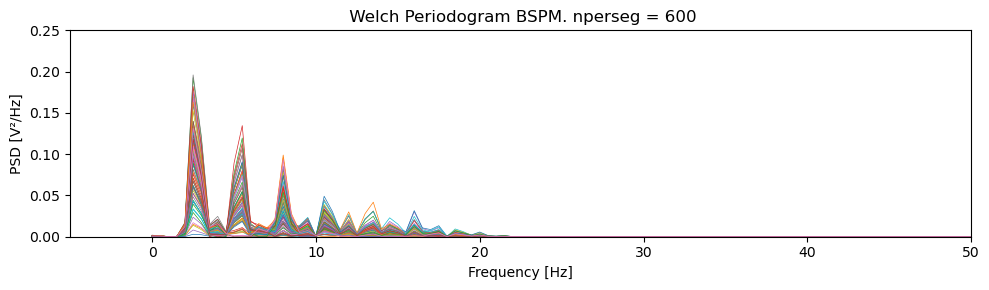

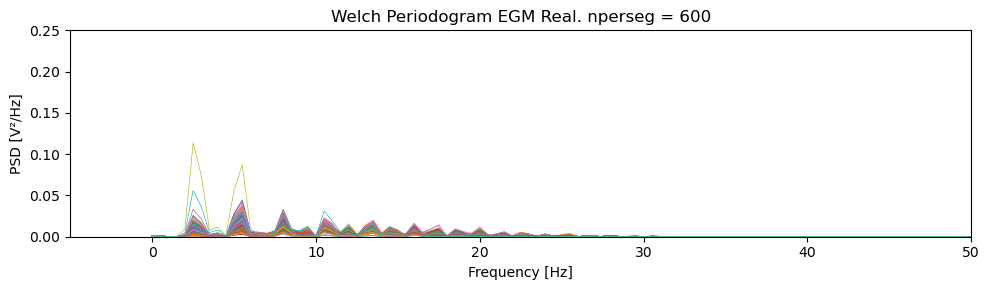

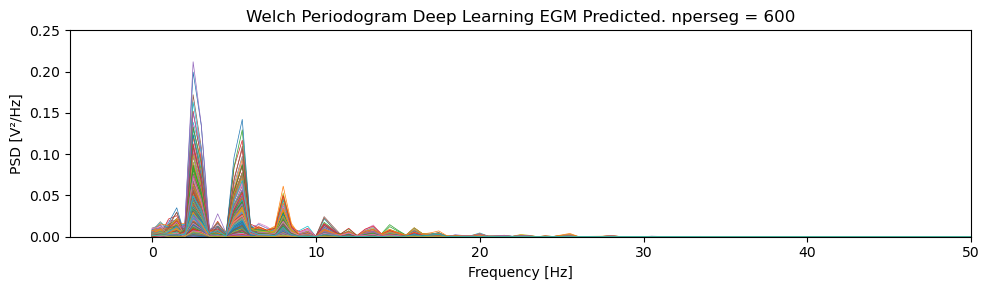

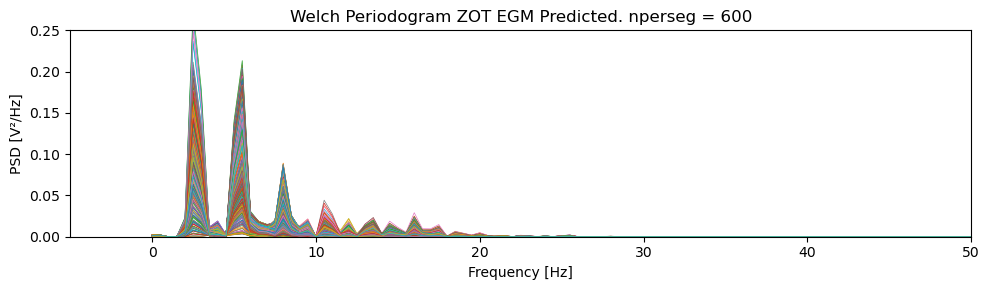

In [117]:
nperseg_value=600
compute_welch_periodogram(X_1channel_centered, fs=fs, nperseg_value=nperseg_value, title=f" Welch Periodogram BSPM. nperseg = {nperseg_value}")
compute_welch_periodogram(egm_centered, fs=fs, nperseg_value=nperseg_value, title=f"Welch Periodogram EGM Real. nperseg = {nperseg_value}")
compute_welch_periodogram(prediction_centered, fs=fs, nperseg_value=nperseg_value, title=f"Welch Periodogram Deep Learning EGM Predicted. nperseg = {nperseg_value}")
compute_welch_periodogram(tik_rec_centered, fs=fs, nperseg_value=nperseg_value, title=f"Welch Periodogram ZOT EGM Predicted. nperseg = {nperseg_value}")

In [57]:
print(tik_rec_centered.shape, egm_centered.shape)

(400, 2048) (400, 2048)


In [58]:
corr_DL=correlation_by_node(prediction_centered, egm_centered)
corr_tik=correlation_by_node(tik_rec_centered, egm_centered)
RMSE_DL=rmse_by_node(prediction_centered, egm_centered)
RMSE_tik=rmse_by_node(tik_rec_centered, egm_centered)


best_node_DL_corr=np.argmax(corr_DL)
worst_node_DL_corr=np.argmin(corr_DL)
best_node_tik_corr=np.argmax(corr_tik)
worst_node_tik_corr=np.argmin(corr_tik)

Computing correlation in : 2048 nodes
Computing correlation in : 2048 nodes
Computing rmse in 2048 columns
Computing rmse in 2048 columns


In [59]:
print('Best node for DL: ', best_node_DL_corr)
print('Worst node for DL: ', worst_node_DL_corr )
print('Best node for tik: ', best_node_tik_corr)
print('Worst node for tik: ', worst_node_tik_corr )

Best node for DL:  2046
Worst node for DL:  1537
Best node for tik:  2046
Worst node for tik:  581


In [60]:
worst_node_DL_rmse=np.argmax(RMSE_DL)
best_node_DL_rmse=np.argmin(RMSE_DL)
worst_node_tik_rmse=np.argmax(RMSE_tik)
best_node_tik_rmse=np.argmin(RMSE_tik)
print('Best node for DL: ', best_node_DL_rmse)
print('Worst node for DL: ', worst_node_DL_rmse )
print('Best node for tik: ', best_node_tik_rmse)
print('Worst node for tik: ', worst_node_tik_rmse )

Best node for DL:  1975
Worst node for DL:  949
Best node for tik:  2046
Worst node for tik:  1182


In [87]:
X_1channel_centered.shape

(400, 384)

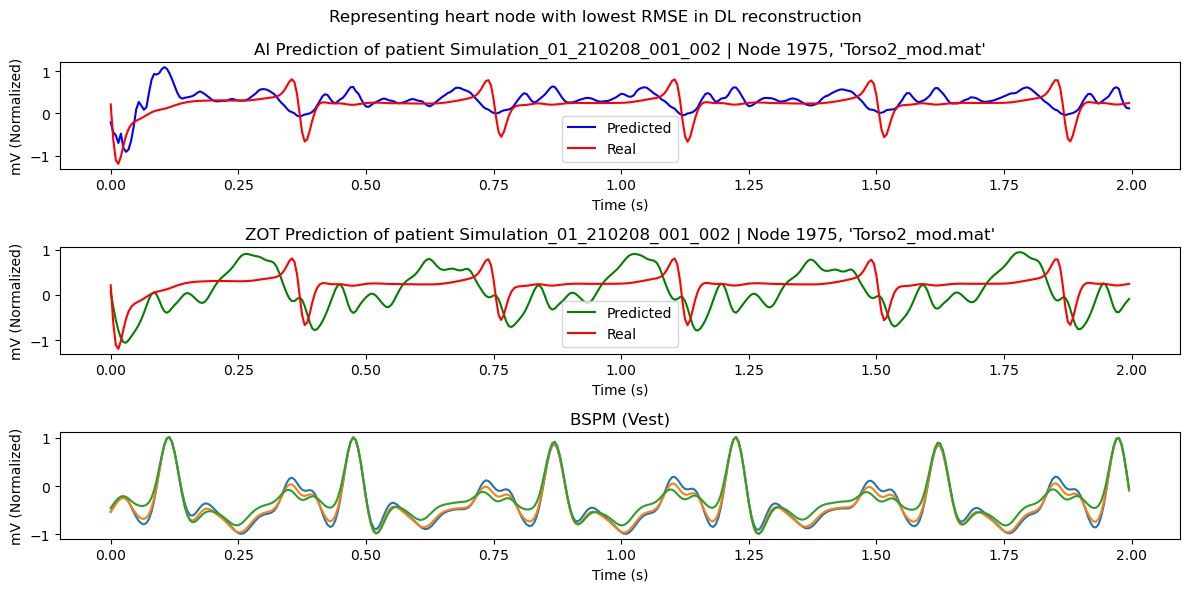

In [88]:
node_num = best_node_DL_rmse
sampling_rate = fs
n_samples = prediction_centered.shape[0]
time_axis = np.arange(n_samples) / sampling_rate  # Eje temporal

plt.figure(figsize=(12, 6), tight_layout=True)

# Subplot 1
plt.subplot(3, 1, 1)
plt.plot(time_axis, prediction_centered[:, node_num], label='Predicted', color="blue")
plt.plot(time_axis, egm_centered[:, node_num], label='Real', color="red")
title = f"AI Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

# Subplot 2
plt.subplot(3, 1, 2)
plt.plot(time_axis, tik_rec_centered[:, node_num], label='Predicted', color="green")
plt.plot(time_axis, egm_centered[:, node_num], label='Real', color="red")
title = f"ZOT Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

# Subplot 3
plt.subplot(3, 1, 3)
plt.plot(time_axis, X_1channel_centered[:, 0:3], label='Predicted')
title = f"BSPM {model_name}, Node {node_num}, {torso_name}"
plt.title('BSPM (Vest)')
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.suptitle('Representing heart node with lowest RMSE in DL reconstruction')

plt.show()


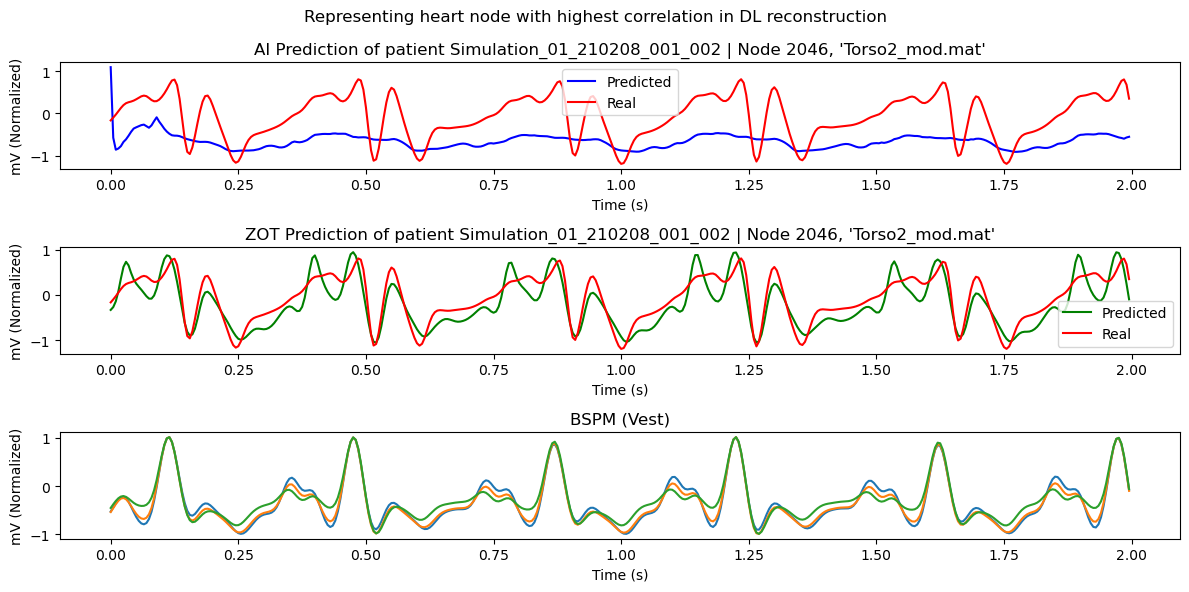

In [89]:
node_num = best_node_DL_corr
sampling_rate = fs  # Frecuencia de muestreo en Hz
n_samples = prediction_centered.shape[0]  # Número de muestras
time_axis = np.arange(n_samples) / sampling_rate  # Eje temporal en segundos

plt.figure(figsize=(12, 6), tight_layout=True)

# Subplot 1
plt.subplot(3, 1, 1)
plt.plot(time_axis, prediction_centered[:, node_num], label='Predicted', color="blue")
plt.plot(time_axis, egm_centered[:, node_num], label='Real', color="red")
title = f"AI Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

# Subplot 2
plt.subplot(3, 1, 2)
plt.plot(time_axis, tik_rec_centered[:, node_num], label='Predicted', color="green")
plt.plot(time_axis, egm_centered[:, node_num], label='Real', color="red")
title = f"ZOT Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

# Subplot 3
plt.subplot(3, 1, 3)
plt.plot(time_axis, X_1channel_centered[:, 0:3], label='Predicted')
title = f"BSPM {model_name}, Node {node_num}, {torso_name}"
plt.title('BSPM (Vest)')
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')

plt.suptitle('Representing heart node with highest correlation in DL reconstruction')
plt.show()


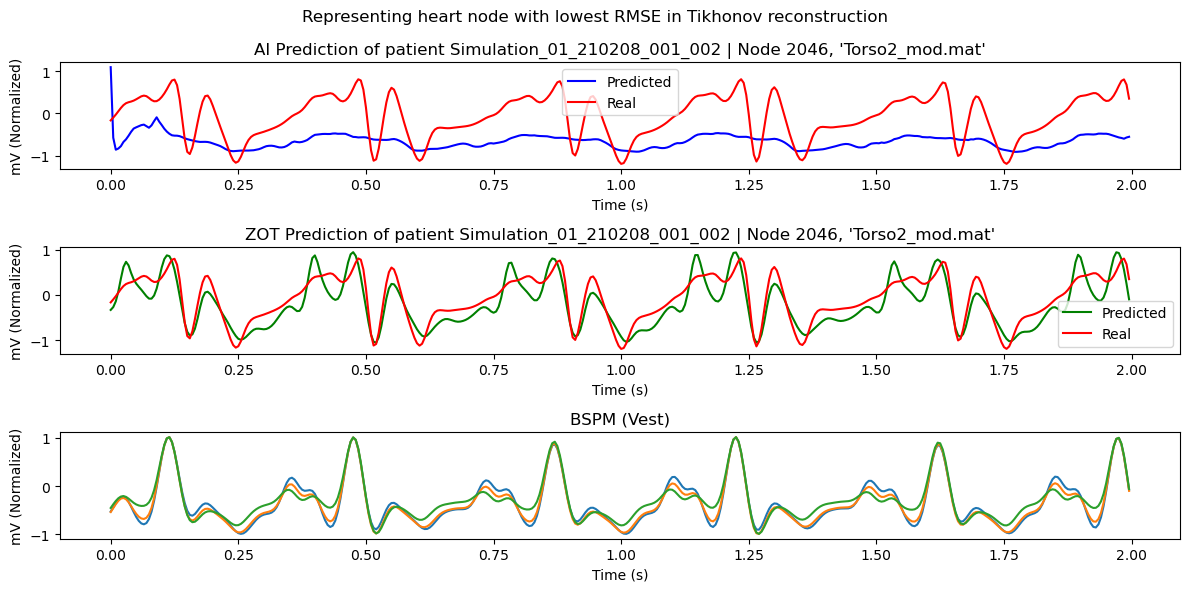

In [90]:
node_num = best_node_tik_rmse
sampling_rate = fs
n_samples = prediction_centered.shape[0]
time_axis = np.arange(n_samples) / sampling_rate  # Eje temporal

plt.figure(figsize=(12, 6), tight_layout=True)

# Subplot 1
plt.subplot(3, 1, 1)
plt.plot(time_axis, prediction_centered[:, node_num], label='Predicted', color="blue")
plt.plot(time_axis, egm_centered[:, node_num], label='Real', color="red")
title = f"AI Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

# Subplot 2
plt.subplot(3, 1, 2)
plt.plot(time_axis, tik_rec_centered[:, node_num], label='Predicted', color="green")
plt.plot(time_axis, egm_centered[:, node_num], label='Real', color="red")
title = f"ZOT Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

# Subplot 3
plt.subplot(3, 1, 3)
plt.plot(time_axis, X_1channel_centered[:, 0:3], label='Predicted')
title = f"BSPM {model_name}, Node {node_num}, {torso_name}"
plt.title('BSPM (Vest)')
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')

plt.suptitle('Representing heart node with lowest RMSE in Tikhonov reconstruction')

plt.show()


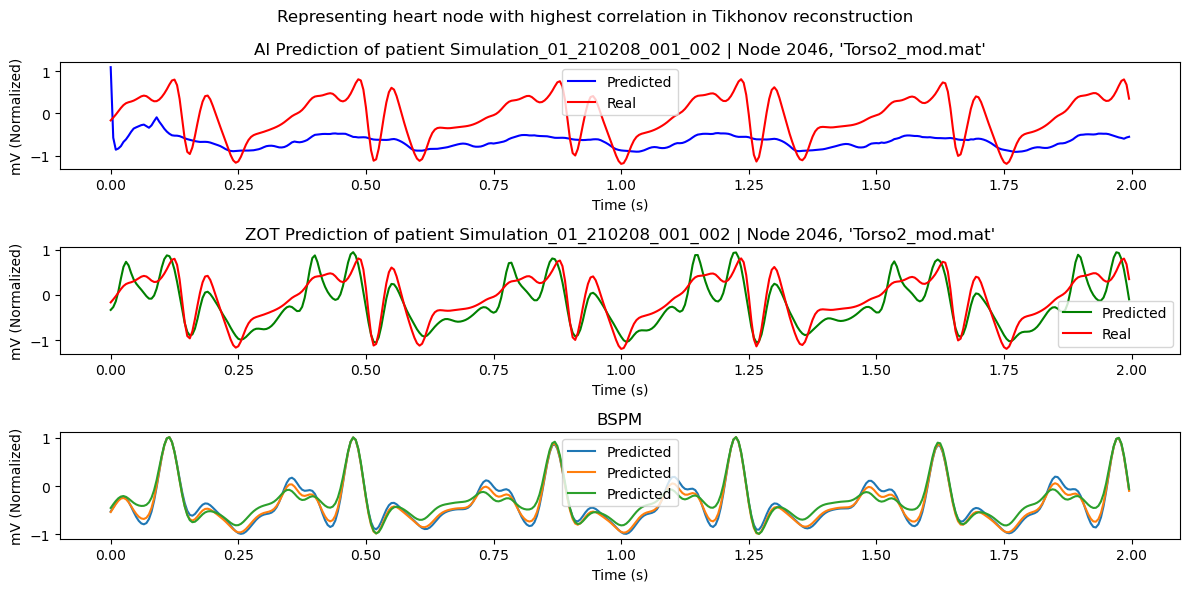

In [91]:
node_num = best_node_tik_corr
sampling_rate = fs
n_samples = prediction_centered.shape[0]
time_axis = np.arange(n_samples) / sampling_rate  # Eje temporal

plt.figure(figsize=(12, 6), tight_layout=True)

# Subplot 1
plt.subplot(3, 1, 1)
plt.plot(time_axis, prediction_centered[:, node_num], label='Predicted', color="blue")
plt.plot(time_axis, egm_centered[:, node_num], label='Real', color='red')
title = f"AI Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

# Subplot 2
plt.subplot(3, 1, 2)
plt.plot(time_axis, tik_rec_centered[:, node_num], label='Predicted', color="green")
plt.plot(time_axis, egm_centered[:, node_num], label='Real', color="red")
title = f"ZOT Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

# Subplot 3
plt.subplot(3, 1, 3)
plt.plot(time_axis, X_1channel_centered[:, 0:3], label='Predicted')
title = f"BSPM {model_name}, Node {node_num}, {torso_name}"
plt.title('BSPM')
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()
plt.suptitle('Representing heart node with highest correlation in Tikhonov reconstruction')

plt.show()


[0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055
 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.105 0.11  0.115
 0.12  0.125 0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175
 0.18  0.185 0.19  0.195 0.2   0.205 0.21  0.215 0.22  0.225 0.23  0.235
 0.24  0.245 0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295
 0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355
 0.36  0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4   0.405 0.41  0.415
 0.42  0.425 0.43  0.435 0.44  0.445 0.45  0.455 0.46  0.465 0.47  0.475
 0.48  0.485 0.49  0.495]


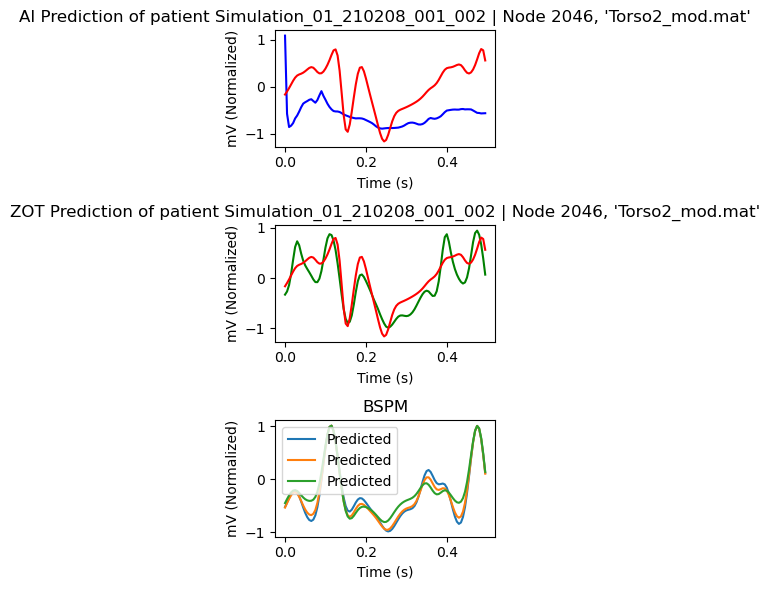

In [92]:
node_num = best_node_DL_corr
sampling_rate = fs  # Frecuencia de muestreo en Hz
n_samples = prediction_centered.shape[0]  # Número de muestras
length_beat=100
time_axis = np.arange(length_beat) / sampling_rate  # Eje temporal en segundos

print(time_axis)

plt.figure(figsize=(3, 6), tight_layout=True)

# Subplot 1
plt.subplot(3, 1, 1)
plt.plot(time_axis, prediction_centered[0:length_beat, node_num], label='Predicted', color="blue")
plt.plot(time_axis, egm_centered[0:length_beat, node_num], label='Real', color="red")
title = f"AI Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
#plt.legend()

# Subplot 2
plt.subplot(3, 1, 2)
plt.plot(time_axis, tik_rec_centered[:length_beat, node_num], label='Predicted', color="green")
plt.plot(time_axis, egm_centered[:length_beat, node_num], label='Real ', color="red")
title = f"ZOT Prediction of patient {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
#plt.legend()

# Subplot 3
plt.subplot(3, 1, 3)
plt.plot(time_axis, X_1channel_centered[:length_beat, 0:3], label='Predicted')
title = f"BSPM {model_name}, Node {node_num}, {torso_name}"
plt.title('BSPM')
plt.xlabel('Time (s)')
plt.ylabel('mV (Normalized)')
plt.legend()

#plt.show()


In [93]:
from scipy.signal import spectrogram

def compute_spectrogram(signal, fs, title, nperseg_value ):

    frequencies, times, Sxx = spectrogram(signal, fs=fs, nperseg=nperseg_value)

    # Graficar el espectrograma
    plt.figure(figsize=(5, 3), tight_layout= True)
    plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
    plt.colorbar(label='PSD (dB/Hz)')
    plt.title(title)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Frecuencia (Hz)')
    plt.ylim(0, 30)  # Mostrar solo hasta la frecuencia de Nyquist
    plt.grid()
    plt.show()

In [101]:
fs

200

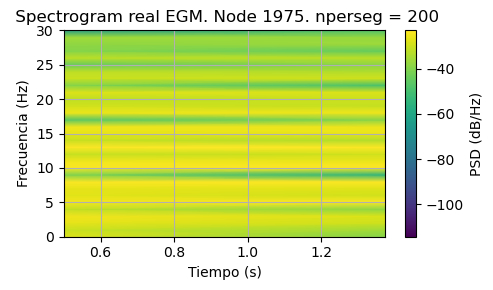

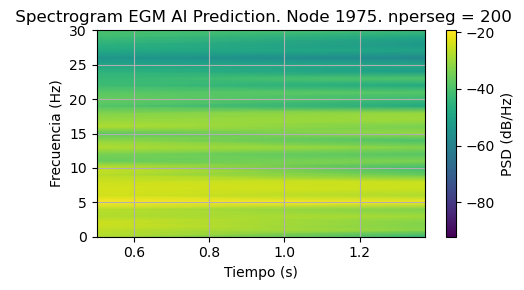

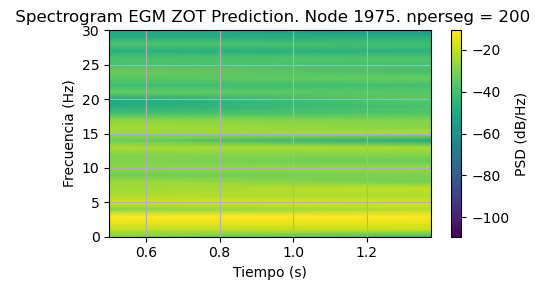

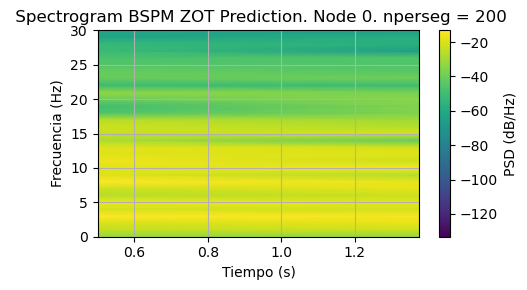

In [108]:
nperseg_value_SP=200
node=best_node_DL_rmse

compute_spectrogram(egm_centered[:, best_node_DL_rmse], fs=fs, nperseg_value=nperseg_value_SP, title=f" Spectrogram real EGM. Node {node}. nperseg = {nperseg_value_SP}")
compute_spectrogram(prediction_centered[:, best_node_DL_rmse], fs=fs, nperseg_value=nperseg_value_SP, title=f" Spectrogram EGM AI Prediction. Node {node}. nperseg = {nperseg_value_SP}")
compute_spectrogram(tik_rec_centered[:, best_node_DL_rmse], fs=fs, nperseg_value=nperseg_value_SP, title=f" Spectrogram EGM ZOT Prediction. Node {node}. nperseg = {nperseg_value_SP}")
compute_spectrogram(X_1channel_centered[:, 0], fs=fs,nperseg_value=nperseg_value_SP, title=f" Spectrogram BSPM ZOT Prediction. Node {0}. nperseg = {nperseg_value_SP}")


In [95]:
np.max(corr_tik)

0.9254774717341984

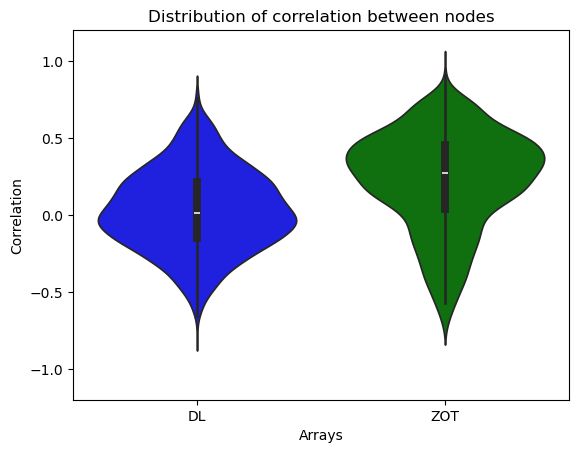

In [96]:

import seaborn as sns
# Combinar los datos en un solo dataset y crear etiquetas
data = [corr_DL, corr_tik]
labels = ['DL', 'ZOT']

# Crear el gráfico de violín
sns.violinplot(data=data,  palette=["blue", "green"])
plt.xticks([0, 1], labels)  # Configurar etiquetas en el eje x
plt.title("Distribution of correlation between nodes")
plt.ylabel("Correlation")
plt.xlabel("Arrays")
plt.ylim([-1.2, 1.2])
plt.show()

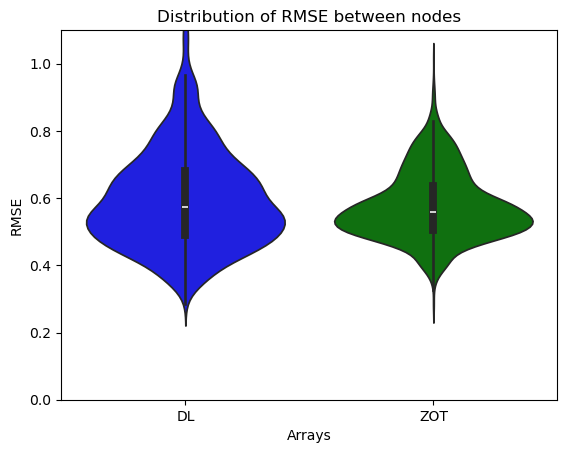

In [97]:

import seaborn as sns
# Combinar los datos en un solo dataset y crear etiquetas
data = [RMSE_DL, RMSE_tik]
labels = ['DL', 'ZOT']

# Crear el gráfico de violín
sns.violinplot(data=data,  palette=["blue", "green"])
plt.xticks([0, 1], labels)  # Configurar etiquetas en el eje x
plt.title("Distribution of RMSE between nodes")
plt.ylabel("RMSE")
plt.xlabel("Arrays")
plt.ylim([0, 1.1])

plt.show()

In [98]:
# Corr local
print('MÉTRICAS LOCALES')
print(model_name, algorithm_ID)
print('Local AI Mean correlation in all heart nodes: ', np.round(np.mean(corr_DL), 3), '+-', np.std(corr_DL))
print('Local ZOT Mean correlation in all heart nodes: ', np.round(np.mean(corr_tik), 3) , '+-', np.std(corr_tik))
# RMSE local
print('Local AI Mean RMSE in all heart nodes: ', np.round(np.mean(RMSE_DL), 3), '+-', np.std(corr_DL))
print('Local ZOT Mean RMSE in all heart nodes: ', np.round(np.mean(RMSE_tik), 3) , '+-', np.std(corr_tik))

MÉTRICAS LOCALES
['Simulation_01_210208_001_002'] OMAMI_repeated
Local AI Mean correlation in all heart nodes:  0.03 +- 0.26155978866993734
Local ZOT Mean correlation in all heart nodes:  0.222 +- 0.318487123087973
Local AI Mean RMSE in all heart nodes:  0.598 +- 0.26155978866993734
Local ZOT Mean RMSE in all heart nodes:  0.577 +- 0.318487123087973
